In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno # for visualizing missing data
from scipy.stats import skew

from utils.plots import plot_density, plot_boxwhisker
from utils.load_data import load_data

### Load Dataset

In [67]:
data_path = '../data/cancer_reg-1.csv'
df = load_data(data_path)
df.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


### Explore general info

#### Number of samples

In [68]:
len(df)

3047

#### Categorical features

In [69]:
df.columns

Index(['avgAnnCount', 'avgDeathsPerYear', 'TARGET_deathRate', 'incidenceRate',
       'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'binnedInc',
       'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'Geography',
       'AvgHouseholdSize', 'PercentMarried', 'PctNoHS18_24', 'PctHS18_24',
       'PctSomeCol18_24', 'PctBachDeg18_24', 'PctHS25_Over',
       'PctBachDeg25_Over', 'PctEmployed16_Over', 'PctUnemployed16_Over',
       'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage',
       'PctPublicCoverage', 'PctPublicCoverageAlone', 'PctWhite', 'PctBlack',
       'PctAsian', 'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate'],
      dtype='object')

Since `TARGET_deathRate` is continuous, this is regression problem.\
It's trying to predict **cancer mortality rates** (`TARGET_deathRate`)based on personal information related features such as education, income, age, geography, race, etc. 

In [70]:
df.dtypes[df.dtypes == 'object']

binnedInc    object
Geography    object
dtype: object

`binnedInc` and `Geography` are object type

In [71]:
cat_df = df[['binnedInc', 'Geography']].copy()

In [72]:
cat_df['State'] = cat_df['Geography'].apply(lambda x: x.split(',')[-1].strip())
cat_df['County'] = cat_df['Geography'].apply(lambda x: x.split(',')[0].strip())
cat_df

,binnedInc,Geography,State,County
0,"(61494.5, 125635]","Kitsap County, Washington",Washington,Kitsap County
1,"(48021.6, 51046.4]","Kittitas County, Washington",Washington,Kittitas County
2,"(48021.6, 51046.4]","Klickitat County, Washington",Washington,Klickitat County
3,"(42724.4, 45201]","Lewis County, Washington",Washington,Lewis County
4,"(48021.6, 51046.4]","Lincoln County, Washington",Washington,Lincoln County
...,...,...,...,...
3042,"(45201, 48021.6]","Ellsworth County, Kansas",Kansas,Ellsworth County
3043,"(48021.6, 51046.4]","Finney County, Kansas",Kansas,Finney County
3044,"(51046.4, 54545.6]","Ford County, Kansas",Kansas,Ford County
3045,"(48021.6, 51046.4]","Franklin County, Kansas",Kansas,Franklin County


Check number of unique states and county

In [73]:
n_states = cat_df['State'].nunique()
n_counties = cat_df['County'].nunique()
print(f'Number of unique states: {n_states}')
print(f'Number of unique counties: {n_counties}')

Number of unique states: 51
Number of unique counties: 1819


#### Numerical features

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   int64  
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   int64  
 5   popEst2015               3047 non-null   int64  
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

There are 33 features, 2 categorical and the rest is numerical

In [75]:
df.describe()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
count,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3.047000e+03,3047.000000,3047.000000,3047.000000,3047.000000,...,2438.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000
mean,606.338544,185.965868,178.664063,448.268586,47063.281917,1.026374e+05,16.878175,155.399415,45.272333,39.570725,...,48.453774,41.196324,36.252642,19.240072,83.645286,9.107978,1.253965,1.983523,51.243872,5.640306
std,1416.356223,504.134286,27.751511,54.560733,12040.090836,3.290592e+05,6.409087,529.628366,45.304480,5.226017,...,10.083006,9.447687,7.841741,6.113041,16.380025,14.534538,2.610276,3.517710,6.572814,1.985816
min,6.000000,3.000000,59.700000,201.300000,22640.000000,8.270000e+02,3.200000,0.000000,22.300000,22.400000,...,15.700000,13.500000,11.200000,2.600000,10.199155,0.000000,0.000000,0.000000,22.992490,0.000000
25%,76.000000,28.000000,161.200000,420.300000,38882.500000,1.168400e+04,12.150000,0.000000,37.700000,36.350000,...,41.000000,34.500000,30.900000,14.850000,77.296180,0.620675,0.254199,0.295172,47.763063,4.521419
50%,171.000000,61.000000,178.100000,453.549422,45207.000000,2.664300e+04,15.900000,0.000000,41.000000,39.600000,...,48.700000,41.100000,36.300000,18.800000,90.059774,2.247576,0.549812,0.826185,51.669941,5.381478
75%,518.000000,149.000000,195.200000,480.850000,52492.000000,6.867100e+04,20.400000,83.650776,44.000000,42.500000,...,55.600000,47.700000,41.550000,23.100000,95.451693,10.509732,1.221037,2.177960,55.395132,6.493677
max,38150.000000,14010.000000,362.800000,1206.900000,125635.000000,1.017029e+07,47.400000,9762.308998,624.000000,64.700000,...,78.900000,70.700000,65.100000,46.600000,100.000000,85.947799,42.619425,41.930251,78.075397,21.326165


Extract the min and max values for each feature

In [76]:
min_vals = df.min(numeric_only=True)
max_vals = df.max(numeric_only=True)
for col in min_vals.index:
    print(f"{col:<25}| MIN = {min_vals[col]:<15} | MAX = {max_vals[col]}")

avgAnnCount              | MIN = 6.0             | MAX = 38150.0
avgDeathsPerYear         | MIN = 3.0             | MAX = 14010.0
TARGET_deathRate         | MIN = 59.7            | MAX = 362.8
incidenceRate            | MIN = 201.3           | MAX = 1206.9
medIncome                | MIN = 22640.0         | MAX = 125635.0
popEst2015               | MIN = 827.0           | MAX = 10170292.0
povertyPercent           | MIN = 3.2             | MAX = 47.4
studyPerCap              | MIN = 0.0             | MAX = 9762.308998
MedianAge                | MIN = 22.3            | MAX = 624.0
MedianAgeMale            | MIN = 22.4            | MAX = 64.7
MedianAgeFemale          | MIN = 22.3            | MAX = 65.7
AvgHouseholdSize         | MIN = 0.0221          | MAX = 3.97
PercentMarried           | MIN = 23.1            | MAX = 72.5
PctNoHS18_24             | MIN = 0.0             | MAX = 64.1
PctHS18_24               | MIN = 0.0             | MAX = 72.5
PctSomeCol18_24          | MIN = 7.1       

Max median age is 624???

In [77]:
df[df['MedianAge'] > 120]

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
100,89.000000,32,152.3,447.200000,61802,17110,8.2,0.000000,"(61494.5, 125635]",458.4,...,67.6,55.0,24.3,9.0,96.476056,0.352983,0.482410,1.194258,60.491493,9.675646
181,564.000000,188,135.7,395.400000,56142,139394,12.6,0.000000,"(54545.6, 61494.5]",469.2,...,NaN,43.1,35.9,21.1,69.971750,2.662510,1.383949,9.734481,51.876656,5.497053
225,346.000000,156,176.8,399.000000,44207,62194,14.6,0.000000,"(42724.4, 45201]",546.0,...,NaN,42.6,36.2,18.6,74.844730,21.417651,0.342389,1.576584,51.591360,4.194566
318,186.000000,93,193.4,406.200000,37122,25345,19.0,0.000000,"(34218.1, 37413.8]",624.0,...,34.2,29.4,53.2,23.4,96.145821,0.625960,0.519665,0.141727,48.108966,4.012841
425,230.000000,98,198.1,477.800000,45841,39259,18.7,0.000000,"(45201, 48021.6]",508.8,...,45.4,37.9,39.3,22.3,68.766237,27.377617,0.430442,1.533289,45.407268,6.140351
606,35.000000,12,188.8,538.800000,36449,4251,17.3,0.000000,"(34218.1, 37413.8]",619.2,...,24.7,20.2,53.8,27.1,98.442662,0.070788,0.165172,0.141576,46.769034,3.333333
637,140.000000,59,193.1,478.000000,66522,25512,6.9,0.000000,"(61494.5, 125635]",498.0,...,65.6,55.4,24.4,9.3,96.813880,0.954259,0.563880,0.339117,61.336613,7.938903
843,599.000000,250,207.1,489.900000,39927,128755,22.5,62.133509,"(37413.8, 40362.7]",412.8,...,41.4,36.4,38.7,23.6,67.091150,29.715665,0.765822,0.362590,45.456544,3.432793
991,85.000000,32,156.5,404.000000,61762,19162,9.6,0.000000,"(61494.5, 125635]",481.2,...,NaN,50.3,26.1,13.8,88.446510,6.584645,1.240891,1.019115,58.641541,3.450672
1199,959.000000,398,206.7,497.400000,41010,201410,18.8,24.824984,"(40362.7, 42724.4]",424.8,...,42.2,32.6,35.9,20.2,69.410704,23.273279,3.041250,1.080156,41.830737,5.131499


Check if there're any missing values in those data with median age > 120

In [78]:
df[df['MedianAge'] > 120].isnull().sum().sort_values(ascending=False)

PctSomeCol18_24            22
PctPrivateCoverageAlone     7
PctEmployed16_Over          3
PctEmpPrivCoverage          0
PctHS25_Over                0
PctBachDeg25_Over           0
PctUnemployed16_Over        0
PctPrivateCoverage          0
PctPublicCoverage           0
avgDeathsPerYear            0
PctPublicCoverageAlone      0
PctWhite                    0
PctBlack                    0
PctAsian                    0
PctOtherRace                0
PctMarriedHouseholds        0
PctBachDeg18_24             0
avgAnnCount                 0
PctHS18_24                  0
PctNoHS18_24                0
PercentMarried              0
AvgHouseholdSize            0
Geography                   0
MedianAgeFemale             0
MedianAgeMale               0
MedianAge                   0
binnedInc                   0
studyPerCap                 0
povertyPercent              0
popEst2015                  0
medIncome                   0
incidenceRate               0
TARGET_deathRate            0
BirthRate 

In [79]:
df[['AvgHouseholdSize']]

,AvgHouseholdSize
0,2.54
1,2.34
2,2.62
3,2.52
4,2.34
...,...
3042,2.08
3043,2.90
3044,3.04
3045,2.56


### Check missing values

In [80]:
df.isna().sum().sort_values(ascending=False) 

PctSomeCol18_24            2285
PctPrivateCoverageAlone     609
PctEmployed16_Over          152
PctEmpPrivCoverage            0
PctHS25_Over                  0
PctBachDeg25_Over             0
PctUnemployed16_Over          0
PctPrivateCoverage            0
PctPublicCoverage             0
avgDeathsPerYear              0
PctPublicCoverageAlone        0
PctWhite                      0
PctBlack                      0
PctAsian                      0
PctOtherRace                  0
PctMarriedHouseholds          0
PctBachDeg18_24               0
avgAnnCount                   0
PctHS18_24                    0
PctNoHS18_24                  0
PercentMarried                0
AvgHouseholdSize              0
Geography                     0
MedianAgeFemale               0
MedianAgeMale                 0
MedianAge                     0
binnedInc                     0
studyPerCap                   0
povertyPercent                0
popEst2015                    0
medIncome                     0
incidenc

Convert to percentage

In [81]:
df.isna().sum().sort_values(ascending=False) / len(df) * 100

PctSomeCol18_24            74.991795
PctPrivateCoverageAlone    19.986872
PctEmployed16_Over          4.988513
PctEmpPrivCoverage          0.000000
PctHS25_Over                0.000000
PctBachDeg25_Over           0.000000
PctUnemployed16_Over        0.000000
PctPrivateCoverage          0.000000
PctPublicCoverage           0.000000
avgDeathsPerYear            0.000000
PctPublicCoverageAlone      0.000000
PctWhite                    0.000000
PctBlack                    0.000000
PctAsian                    0.000000
PctOtherRace                0.000000
PctMarriedHouseholds        0.000000
PctBachDeg18_24             0.000000
avgAnnCount                 0.000000
PctHS18_24                  0.000000
PctNoHS18_24                0.000000
PercentMarried              0.000000
AvgHouseholdSize            0.000000
Geography                   0.000000
MedianAgeFemale             0.000000
MedianAgeMale               0.000000
MedianAge                   0.000000
binnedInc                   0.000000
s

Since there're many missing data here (~75% of the dataset), we won't remove the rows with missing features.

#### Check if there are any dudplicated values for each column

In [82]:
df.nunique().sort_values()

binnedInc                    10
PctUnemployed16_Over        195
AvgHouseholdSize            199
PctBachDeg18_24             219
PctBachDeg25_Over           281
MedianAgeFemale             296
MedianAgeMale               298
PctPublicCoverageAlone      319
MedianAge                   325
povertyPercent              333
PctSomeCol18_24             343
PctHS25_Over                361
PercentMarried              362
PctPublicCoverage           395
PctNoHS18_24                405
PctEmployed16_Over          409
PctEmpPrivCoverage          450
PctPrivateCoverageAlone     459
PctHS18_24                  469
PctPrivateCoverage          498
avgDeathsPerYear            608
avgAnnCount                 929
TARGET_deathRate           1053
studyPerCap                1117
incidenceRate              1506
PctAsian                   2852
PctOtherRace               2903
medIncome                  2920
PctBlack                   2972
popEst2015                 2999
BirthRate                  3019
PctMarri

#### Plot nullity matrix

<Axes: >

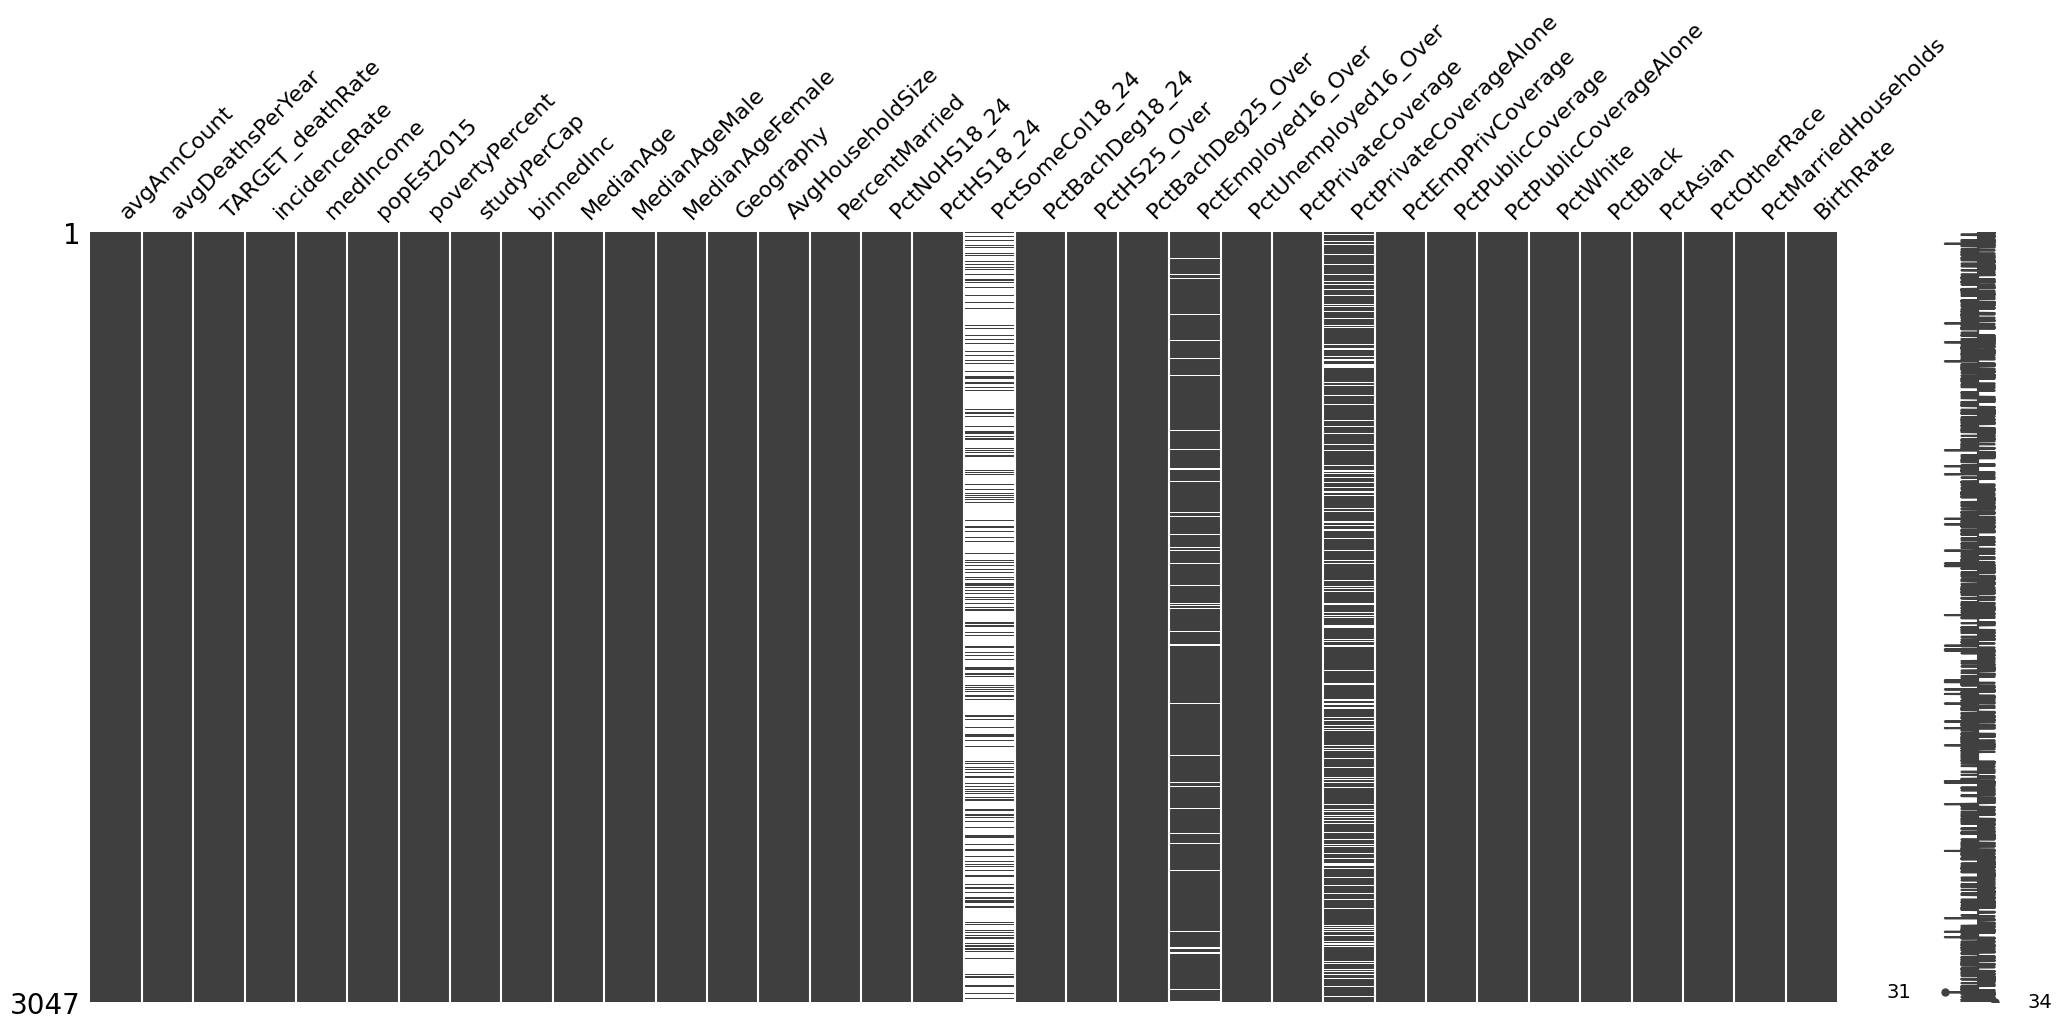

In [83]:
msno.matrix(df)

In [84]:
zoom_df = df[['PctSomeCol18_24', 'PctBachDeg18_24', 'PctBachDeg25_Over', 'PctPrivateCoverageAlone', 'PctEmployed16_Over', 'TARGET_deathRate']]
zoom_df.describe()

,PctSomeCol18_24,PctBachDeg18_24,PctBachDeg25_Over,PctPrivateCoverageAlone,PctEmployed16_Over,TARGET_deathRate
count,762.000000,3047.000000,3047.000000,2438.000000,2895.000000,3047.000000
mean,40.977034,6.158287,13.282015,48.453774,54.152642,178.664063
std,11.115805,4.529059,5.394756,10.083006,8.315064,27.751511
min,7.100000,0.000000,2.500000,15.700000,17.600000,59.700000
25%,34.000000,3.100000,9.400000,41.000000,48.600000,161.200000
50%,40.400000,5.400000,12.300000,48.700000,54.500000,178.100000
75%,46.400000,8.200000,16.100000,55.600000,60.300000,195.200000
max,79.000000,51.800000,42.200000,78.900000,80.100000,362.800000


In [85]:
zoom_df.head(10)

,PctSomeCol18_24,PctBachDeg18_24,PctBachDeg25_Over,PctPrivateCoverageAlone,PctEmployed16_Over,TARGET_deathRate
0,42.1,6.9,19.6,NaN,51.9,164.9
1,64.0,7.5,22.7,53.8,55.9,161.3
2,NaN,9.5,16.0,43.5,45.9,174.7
3,36.1,2.5,9.3,40.3,48.3,194.8
4,40.0,2.0,15.0,43.9,48.2,144.4
5,NaN,4.5,11.9,38.8,44.1,176.0
6,NaN,5.8,11.9,35.0,51.8,175.9
7,36.5,2.2,11.3,33.1,40.9,183.6
8,NaN,1.4,12.0,37.8,39.5,190.5
9,NaN,7.1,16.2,NaN,56.6,177.8


### Plot correlation matrix

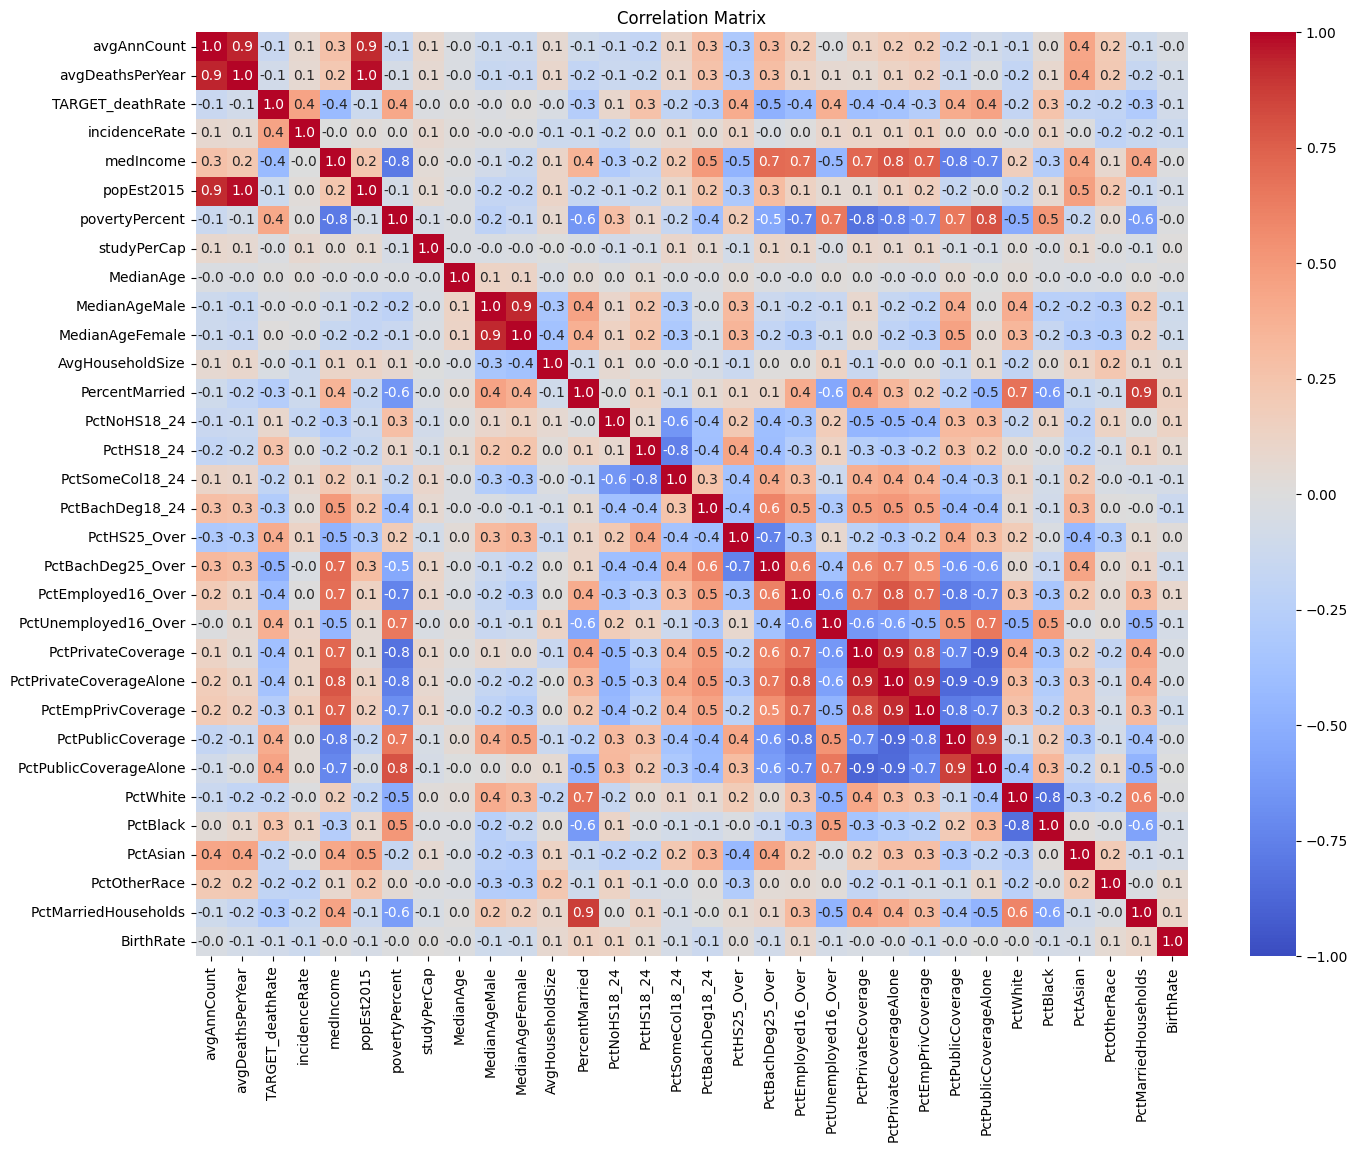

In [86]:
plt.figure(figsize=(16, 12))
correlation_matrix = df[df.select_dtypes(include=['float64', 'int64']).columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [87]:
obj_features = df.select_dtypes(include=['object'])
obj_features.head(10)

,binnedInc,Geography
0,"(61494.5, 125635]","Kitsap County, Washington"
1,"(48021.6, 51046.4]","Kittitas County, Washington"
2,"(48021.6, 51046.4]","Klickitat County, Washington"
3,"(42724.4, 45201]","Lewis County, Washington"
4,"(48021.6, 51046.4]","Lincoln County, Washington"
5,"(51046.4, 54545.6]","Mason County, Washington"
6,"(37413.8, 40362.7]","Okanogan County, Washington"
7,"(37413.8, 40362.7]","Pacific County, Washington"
8,"(40362.7, 42724.4]","Pend Oreille County, Washington"
9,"(54545.6, 61494.5]","Pierce County, Washington"


In [88]:
obj_features.describe()

,binnedInc,Geography
count,3047,3047
unique,10,3047
top,"(54545.6, 61494.5]","Kitsap County, Washington"
freq,306,1


In [89]:
# Just for testing
a = '(5000, 20000]'
a.strip('()[]').split(',')

['5000', ' 20000']

In [90]:
def compute_mean(bin_income):
    """Compute the mean of a string like '(5000, 20000]'"""
    bin_income = bin_income.strip('()[]')
    lower, upper = bin_income.split(',')
    return (float(lower) + float(upper)) / 2


In [91]:
income_df = df[['binnedInc', 'medIncome']].copy()  
income_df.loc[:, 'computedMean'] = income_df['binnedInc'].apply(compute_mean)

income_df.head(10)

,binnedInc,medIncome,computedMean
0,"(61494.5, 125635]",61898,93564.75
1,"(48021.6, 51046.4]",48127,49534.00
2,"(48021.6, 51046.4]",49348,49534.00
3,"(42724.4, 45201]",44243,43962.70
4,"(48021.6, 51046.4]",49955,49534.00
5,"(51046.4, 54545.6]",52313,52796.00
6,"(37413.8, 40362.7]",37782,38888.25
7,"(37413.8, 40362.7]",40189,38888.25
8,"(40362.7, 42724.4]",42579,41543.55
9,"(54545.6, 61494.5]",60397,58020.05


### Check data skewness

In [92]:
num_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
skewed_feats = df[num_features].apply(lambda x: skew(x.dropna()))

In [93]:
skewed_feats.sort_values(ascending=False)

popEst2015                 14.282891
avgDeathsPerYear           11.943305
avgAnnCount                10.675202
MedianAge                   9.985026
studyPerCap                 8.709400
PctAsian                    7.414388
PctOtherRace                4.949741
PctBlack                    2.256957
PctBachDeg18_24             1.955238
medIncome                   1.407377
BirthRate                   1.322551
PctBachDeg25_Over           1.094298
PctNoHS18_24                0.972866
povertyPercent              0.930254
PctUnemployed16_Over        0.890622
incidenceRate               0.771555
PctPublicCoverageAlone      0.470717
PctSomeCol18_24             0.391638
TARGET_deathRate            0.274589
PctHS18_24                  0.179121
MedianAgeMale               0.131976
PctEmpPrivCoverage          0.089372
PctPublicCoverage          -0.005433
PctPrivateCoverageAlone    -0.009909
MedianAgeFemale            -0.208281
PctHS25_Over               -0.333471
PctEmployed16_Over         -0.387448
P

#### Plot all density function for each numerical feature

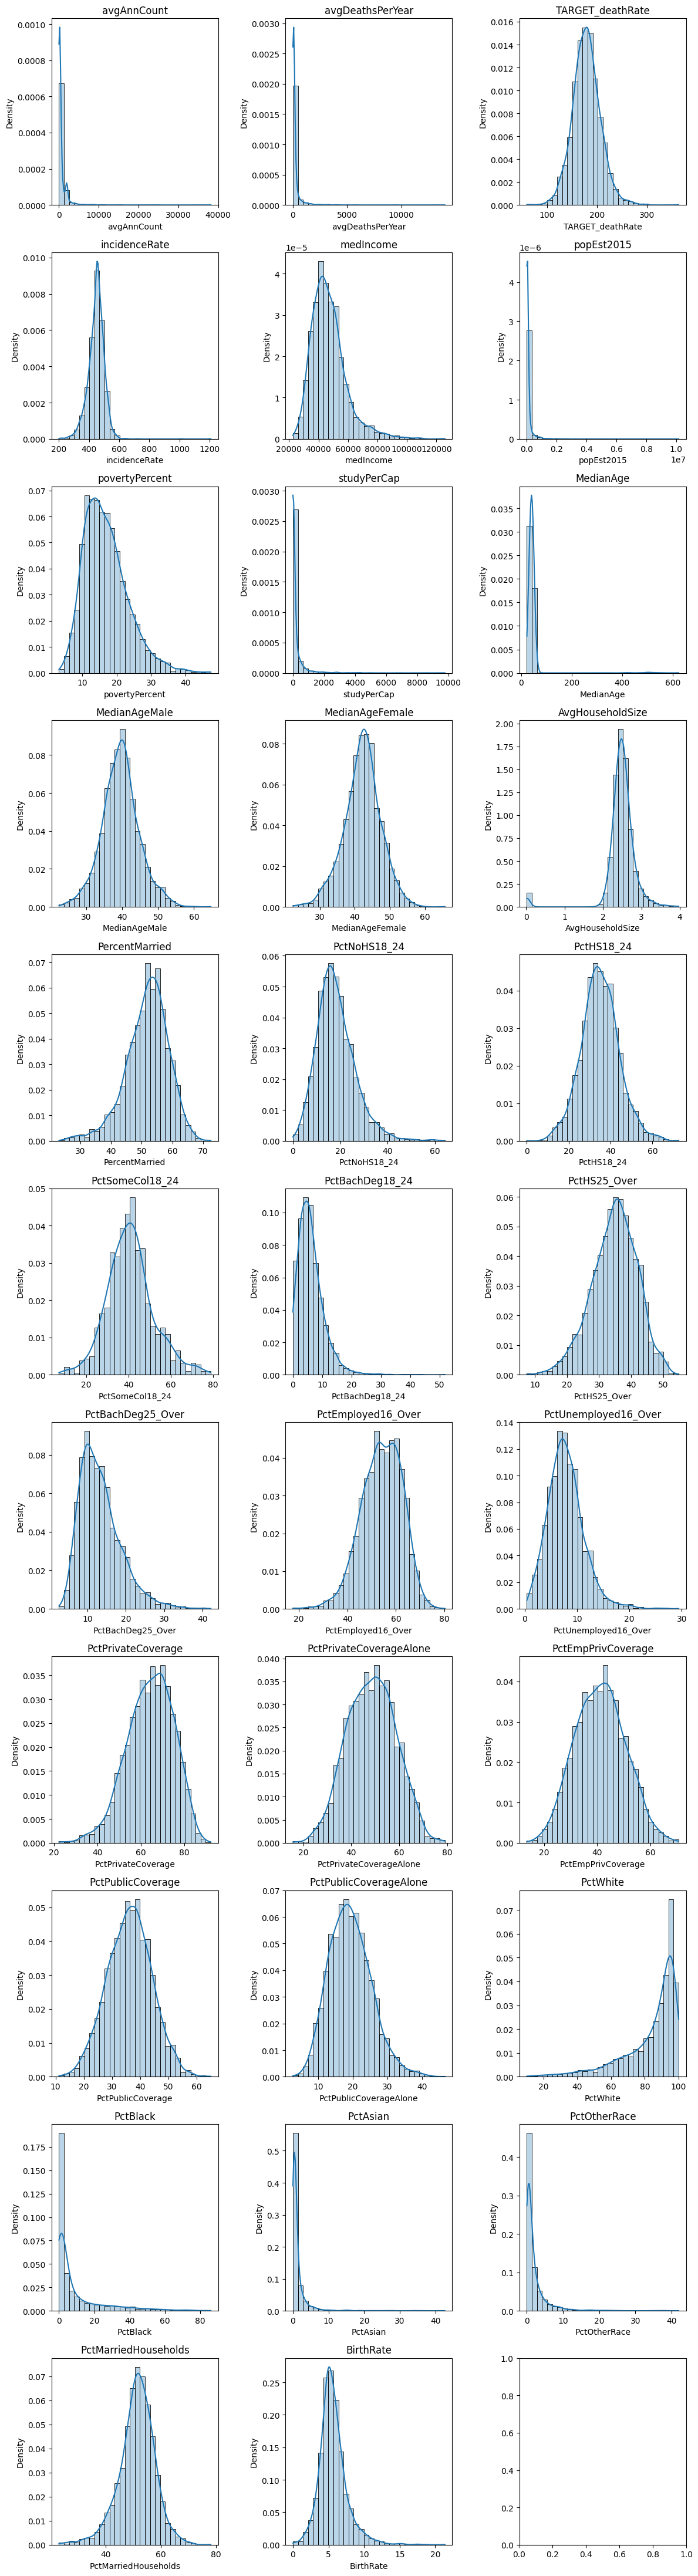

In [94]:
plot_density(df, num_cols=3)

We can observe that some features are highly right-skewed due to outliers. We'll use log transform when preprocessing later.


It's important to notice that our target label is normally distributed with the mean of ~200

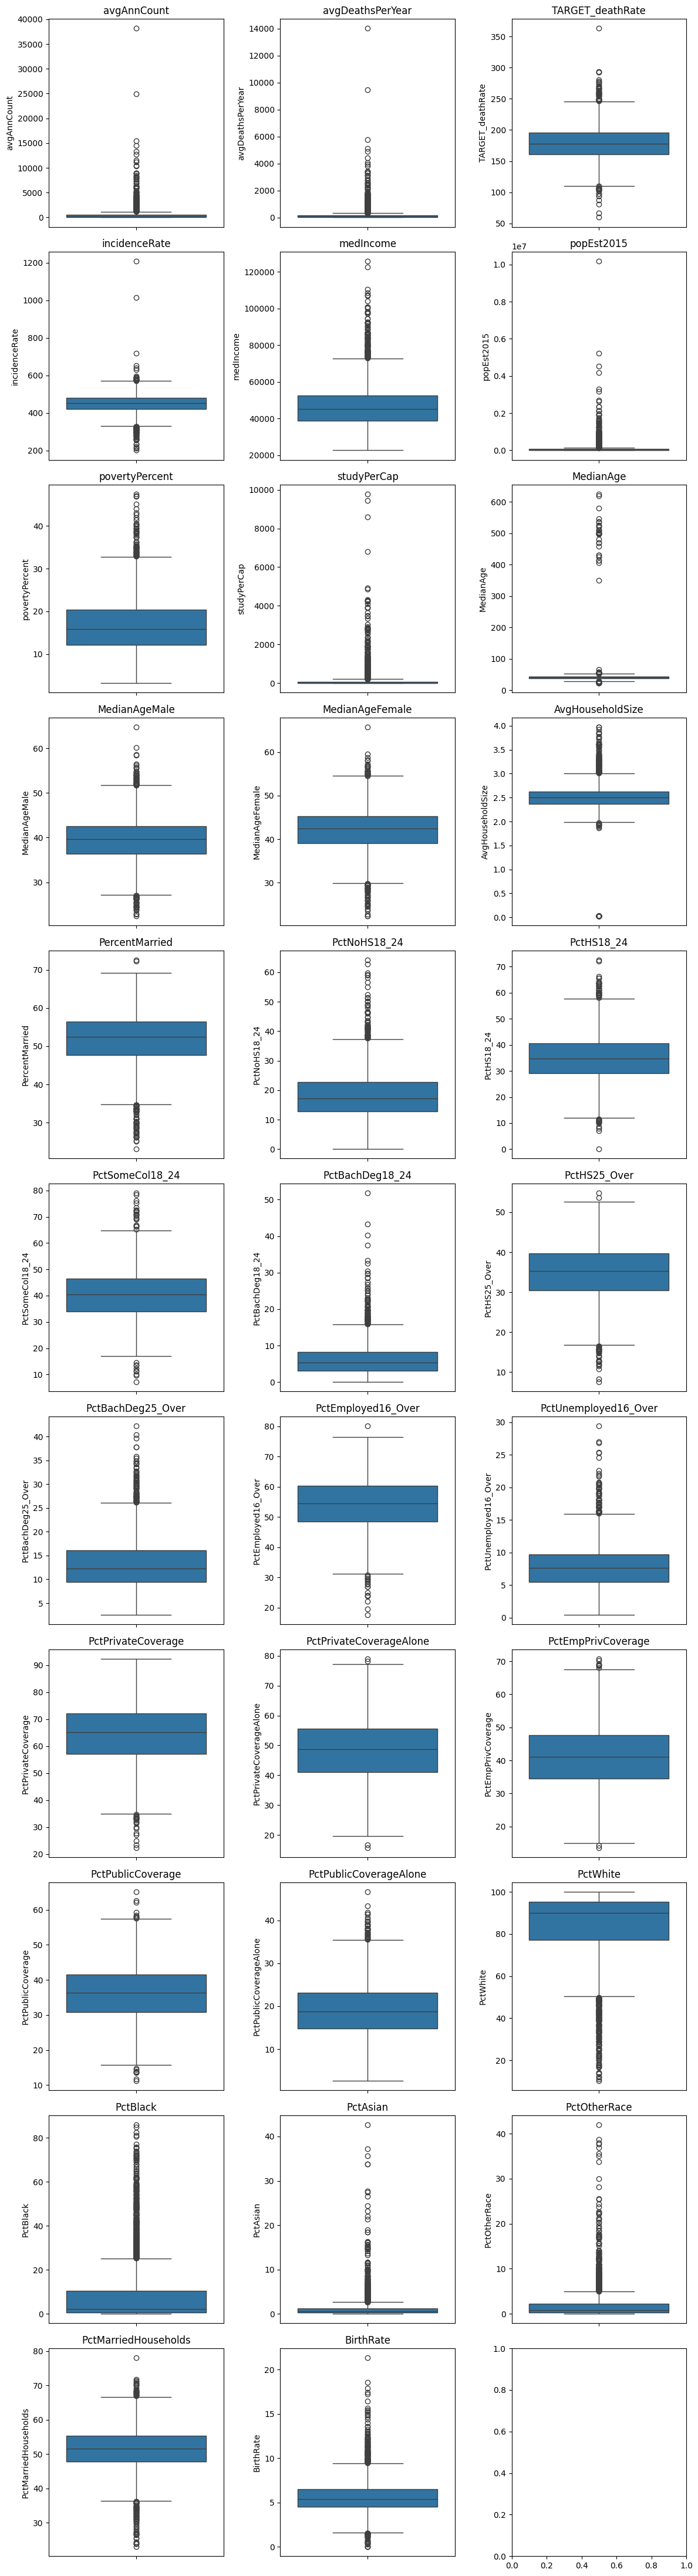

In [95]:
plot_boxwhisker(df, num_cols=3)